## Example 1. Demonstrate data wrangling, and plot a horizontal bar chart

In [1]:
# Step 1: Make the necessary step
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the csv file
pokemon = pd.read_csv('pokemon.csv')
print(pokemon.shape)
pokemon.head(10)

(807, 14)


,id,species,generation_id,height,weight,base_experience,type_1,type_2,hp,attack,defense,speed,special-attack,special-defense
0,1,bulbasaur,1,0.7,6.9,64,grass,poison,45,49,49,45,65,65
1,2,ivysaur,1,1.0,13.0,142,grass,poison,60,62,63,60,80,80
2,3,venusaur,1,2.0,100.0,236,grass,poison,80,82,83,80,100,100
3,4,charmander,1,0.6,8.5,62,fire,NaN,39,52,43,65,60,50
4,5,charmeleon,1,1.1,19.0,142,fire,NaN,58,64,58,80,80,65
5,6,charizard,1,1.7,90.5,240,fire,flying,78,84,78,100,109,85
6,7,squirtle,1,0.5,9.0,63,water,NaN,44,48,65,43,50,64
7,8,wartortle,1,1.0,22.5,142,water,NaN,59,63,80,58,65,80
8,9,blastoise,1,1.6,85.5,239,water,NaN,79,83,100,78,85,105
9,10,caterpie,1,0.3,2.9,39,bug,NaN,45,30,35,45,20,20


In [2]:
# Example 1 - Step 2. Data wrangling to reshape the pokemon dataframe
pkmn_types = pokemon.melt(id_vars=['id', 'species'],
                          value_vars=['type_1','type_2'],
                          var_name='type_level',
                          value_name='type')

pkmn_types.head(10)

,id,species,type_level,type
0,1,bulbasaur,type_1,grass
1,2,ivysaur,type_1,grass
2,3,venusaur,type_1,grass
3,4,charmander,type_1,fire
4,5,charmeleon,type_1,fire
5,6,charizard,type_1,fire
6,7,squirtle,type_1,water
7,8,wartortle,type_1,water
8,9,blastoise,type_1,water
9,10,caterpie,type_1,bug


In [4]:
# Step 3. Find the frequency of unique values in the type column
type_counts = pkmn_types['type'].value_counts()
type_counts

type
water       131
normal      109
flying       98
grass        97
psychic      82
bug          77
poison       66
ground       64
fire         64
rock         60
fighting     54
electric     48
fairy        47
steel        47
dark         46
dragon       45
ghost        43
ice          34
Name: count, dtype: int64

In [5]:
type_order=type_counts.index

In [6]:
type_order

Index(['water', 'normal', 'flying', 'grass', 'psychic', 'bug', 'poison',
       'ground', 'fire', 'rock', 'fighting', 'electric', 'fairy', 'steel',
       'dark', 'dragon', 'ghost', 'ice'],
      dtype='object', name='type')

<Axes: xlabel='count', ylabel='type'>

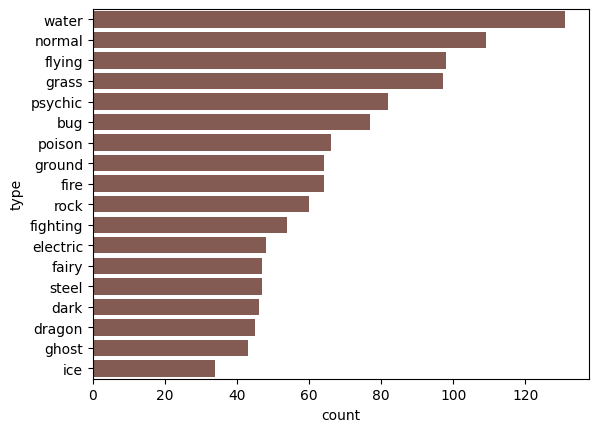

In [13]:
# Example 1 - Step 4. Plot the horizontal bar charts
base_color = sns.color_palette()[5]
sns.countplot(data=pkmn_types, y='type', color=base_color, order=type_order)

In [22]:
# Example 2
# Step 1. Find the maximum proportion of bar

n_pokemon = pkmn_types['type'].value_counts().sum()
print(n_pokemon)

# Return the highest frequency in the `type` column
# iloc[0] retrieves the value at position 0 (the first item) in the Series
max_type_count = type_counts.iloc[0]
print(max_type_count)


# Return the maximum proportion, or in other words, 
# compute the length of the longest bar in terms of the proportion
max_prop = max_type_count / n_pokemon
print(max_prop)


1212
131
0.10808580858085809


In [24]:
# Use numpy.arange() function to produce a set of evenly spaced proportioned values 
# between 0 and max_prop, with a step size 0.02

tick_props = np.arange(0, max_prop, 0.02)
print(tick_props)

[0.   0.02 0.04 0.06 0.08 0.1 ]


In [25]:
# # Use a list comprehension to create tick_names that we will apply to the tick labels. 
# Pick each element `v` from the `tick_props`, and convert it into a formatted string.
# `{:0.2f}` denotes that before formatting, we 2 digits of precision and `f` is used to represent floating point number.
# Refer [here](https://docs.python.org/2/library/string.html#format-string-syntax) for more details

tick_names = ['{:0.2f}'.format(v) for v in tick_props]
tick_names

['0.00', '0.02', '0.04', '0.06', '0.08', '0.10']

Text(0, 0.5, 'proportion')

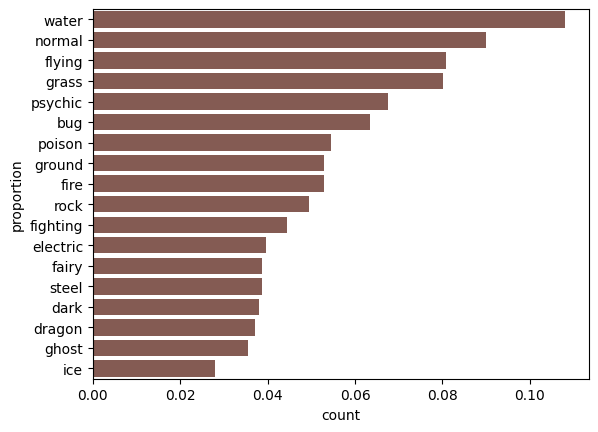

In [30]:
# Step 4. Plot the bar chart, with new x-tick labels

sns.countplot(data=pkmn_types, y='type', color=base_color, order=type_order)

# Change the tick locations and labels
plt.xticks(tick_props * n_pokemon, tick_names)
plt.ylabel('proportion')

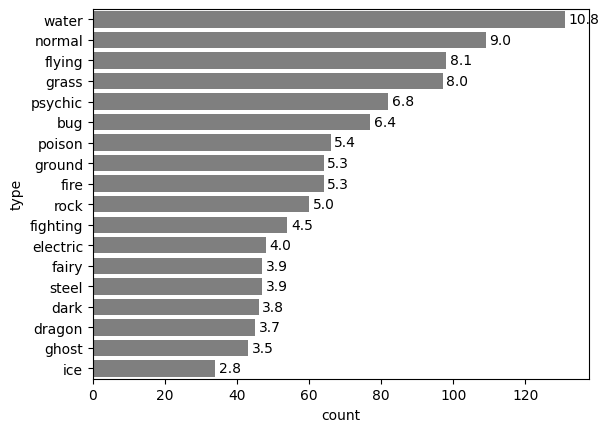

In [34]:
# Example 3. Print the text (proportion) on the bars of a horizontal plot.
# Considering the same chart from the Example 1 above, print the text (proportion) on the bars

base_color = sns.color_palette()[7]
sns.countplot(data=pkmn_types, y='type', color=base_color, order=type_order)

# logic to print the propotional text on horizontal bars
for i in range (type_counts.shape[0]):
    # Remember, type_counts contains the frequency of unique values in the `type` column in decreasing order.
    count = type_counts.iloc[i]
    # Convert count into a percentage, and then into string
    pct_string = '{:0.1f}'.format(100*count/n_pokemon)
    # Print the string value on the bar.
    # Read more about the arguments of text() function [here](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.text.html)
    plt.text(count+1, i, pct_string, va='center')



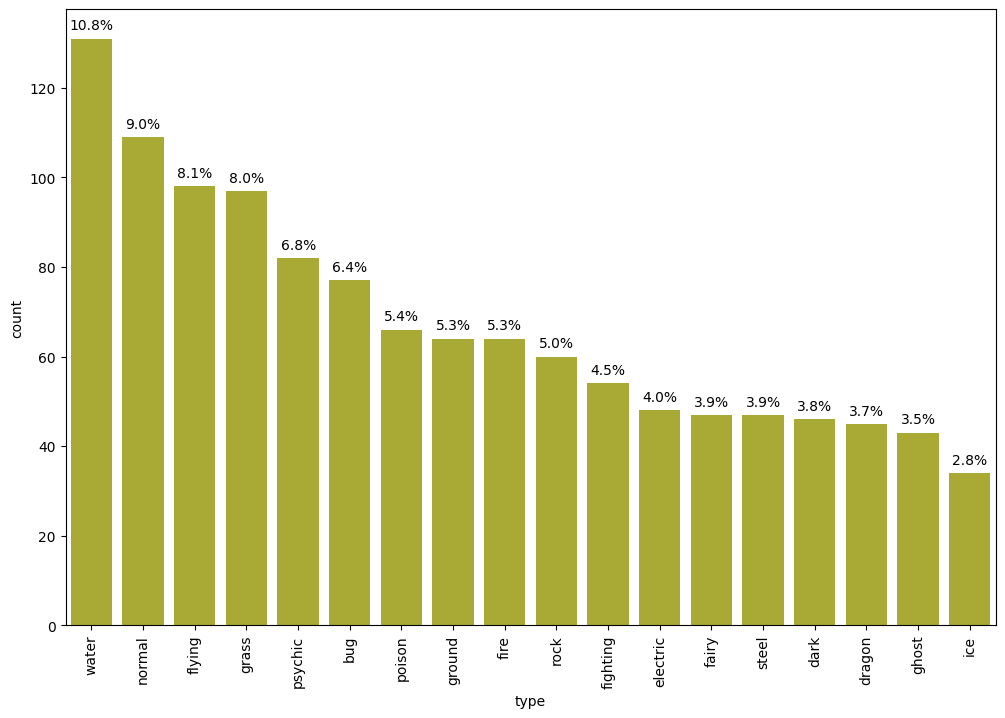

In [38]:
# Example 4. Print the text (proportion) below the bars of a Vertical plot
base_color = sns.color_palette()[8]
sns.countplot(data=pkmn_types, x='type', color=base_color, order=type_order)

# Recalculating the type_counts just to have clarity.
types_count = pkmn_types['type'].value_counts()

# get the current tick locations and labels
locs, labels = plt.xticks(rotation=90)

# loop through each pair of locations and labels
for loc, label in zip(locs, labels):

    count = type_counts[label.get_text()]
    pct_string = '{:0.1f}%'.format(100*count/n_pokemon)

    plt.text(loc, count+2, pct_string, ha = 'center', color='black')

from matplotlib import rcParams
# Specify the figure size in inches, for both X, and Y axes
rcParams['figure.figsize'] = 12, 8

In [37]:
from matplotlib import rcParams
# Specify the figure size in inches, for both X, and Y axes
rcParams['figure.figsize'] = 12, 8